In [5]:
!pip install mplsoccer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import seaborn as sns
import mplsoccer as ms
from mplsoccer import Pitch, Sbopen, VerticalPitch

In [6]:
parser = Sbopen()

seasons = [27]  # 2015/16 season
all_events = []

for season_id in seasons:
    df_matches_epl = parser.match(competition_id=2, season_id=season_id)
    for match_id in df_matches_epl.match_id.unique():
        df_event = parser.event(match_id)[0]
        df_event['match_id'] = match_id
        df_event['league'] = 'Premier League'
        df_event['match_date'] = df_matches_epl.loc[
            df_matches_epl['match_id'] == match_id, 'match_date'].values[0]
        all_events.append(df_event)

    df_matches_laliga = parser.match(competition_id=11, season_id=season_id)
    for match_id in df_matches_laliga.match_id.unique():
        df_event = parser.event(match_id)[0]
        df_event['match_id'] = match_id
        df_event['league'] = 'La Liga'
        df_event['match_date'] = df_matches_laliga.loc[
            df_matches_laliga['match_id'] == match_id, 'match_date'].values[0]
        all_events.append(df_event)

# all event data
df = pd.concat(all_events, ignore_index = True)

In [7]:
df.sort_values(by=['league', 'match_date'], inplace=True)

In [29]:
# filtering only passes made by goalkeepers, and further removing the outcomes we don't need
gk_passes = df[(df['type_name'] == 'Pass') & (df['position_name'] == 'Goalkeeper')]
gk_passes = gk_passes[~gk_passes['outcome_name'].isin(['Pass Offside', 'Injury Clearance', 'Unknown'])]

In [31]:
gk_passes['pass_success'] = gk_passes['outcome_name'].isna().astype(int)

building the expected risk (xRisk) model

In [63]:
# defining the target variable: a successful pass
y = gk_passes['pass_success']

In [114]:
gk_passes['abs_pass_angle'] = gk_passes['pass_angle'].abs()

In [115]:
# defining the features: stuff that might make a pass risky
features = [
    'minute',
    'pass_length',
    'abs_pass_angle',
    'under_pressure',
    'pass_height_name']

In [116]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X = gk_passes[features].copy()
y = y

X['under_pressure'] = X['under_pressure'].fillna(0).astype(int) # binary for under_pressure
X_final = pd.get_dummies(X, columns=['pass_height_name'], drop_first = True) # one-hot encoding for the categorical variable 'pass_height_name'

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size = 0.3, random_state = 14)

logistic regression

In [118]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# initializing and train the logistic regression model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

# predictions
y_pred = logreg_model.predict(X_test)
y_pred_prob = logreg_model.predict_proba(X_test)[:,1]  # probability of success

# commputing xRisk
gk_passes.loc[X_test.index, 'pred_prob_success'] = y_pred_prob
gk_passes.loc[X_test.index, 'xRisk'] = 1 - y_pred_prob

# evaluating the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix for Logistic Regression:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7606793993293482
ROC-AUC: 0.8397297194411664

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.88      0.75      5543
           1       0.89      0.68      0.77      8175

    accuracy                           0.76     13718
   macro avg       0.77      0.78      0.76     13718
weighted avg       0.79      0.76      0.76     13718


Confusion Matrix for Logistic Regression:
 [[4874  669]
 [2614 5561]]


In [124]:
# feature names after one-hot encoding
feature_names = X_train.columns

# coefficients from the trained logistic regression
coefficients = logreg_model.coef_[0]  # binary logistic regression

# combining into a df
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients})

# sorting by absolute impact
coef_df['abs_coeff'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values(by='abs_coeff', ascending=False).drop(columns='abs_coeff')

# Display
print(coef_df)

                      feature  coefficient
4  pass_height_name_High Pass    -3.319681
5   pass_height_name_Low Pass    -2.113971
2              abs_pass_angle     1.395368
3              under_pressure    -0.754380
1                 pass_length    -0.030444
0                      minute     0.000761


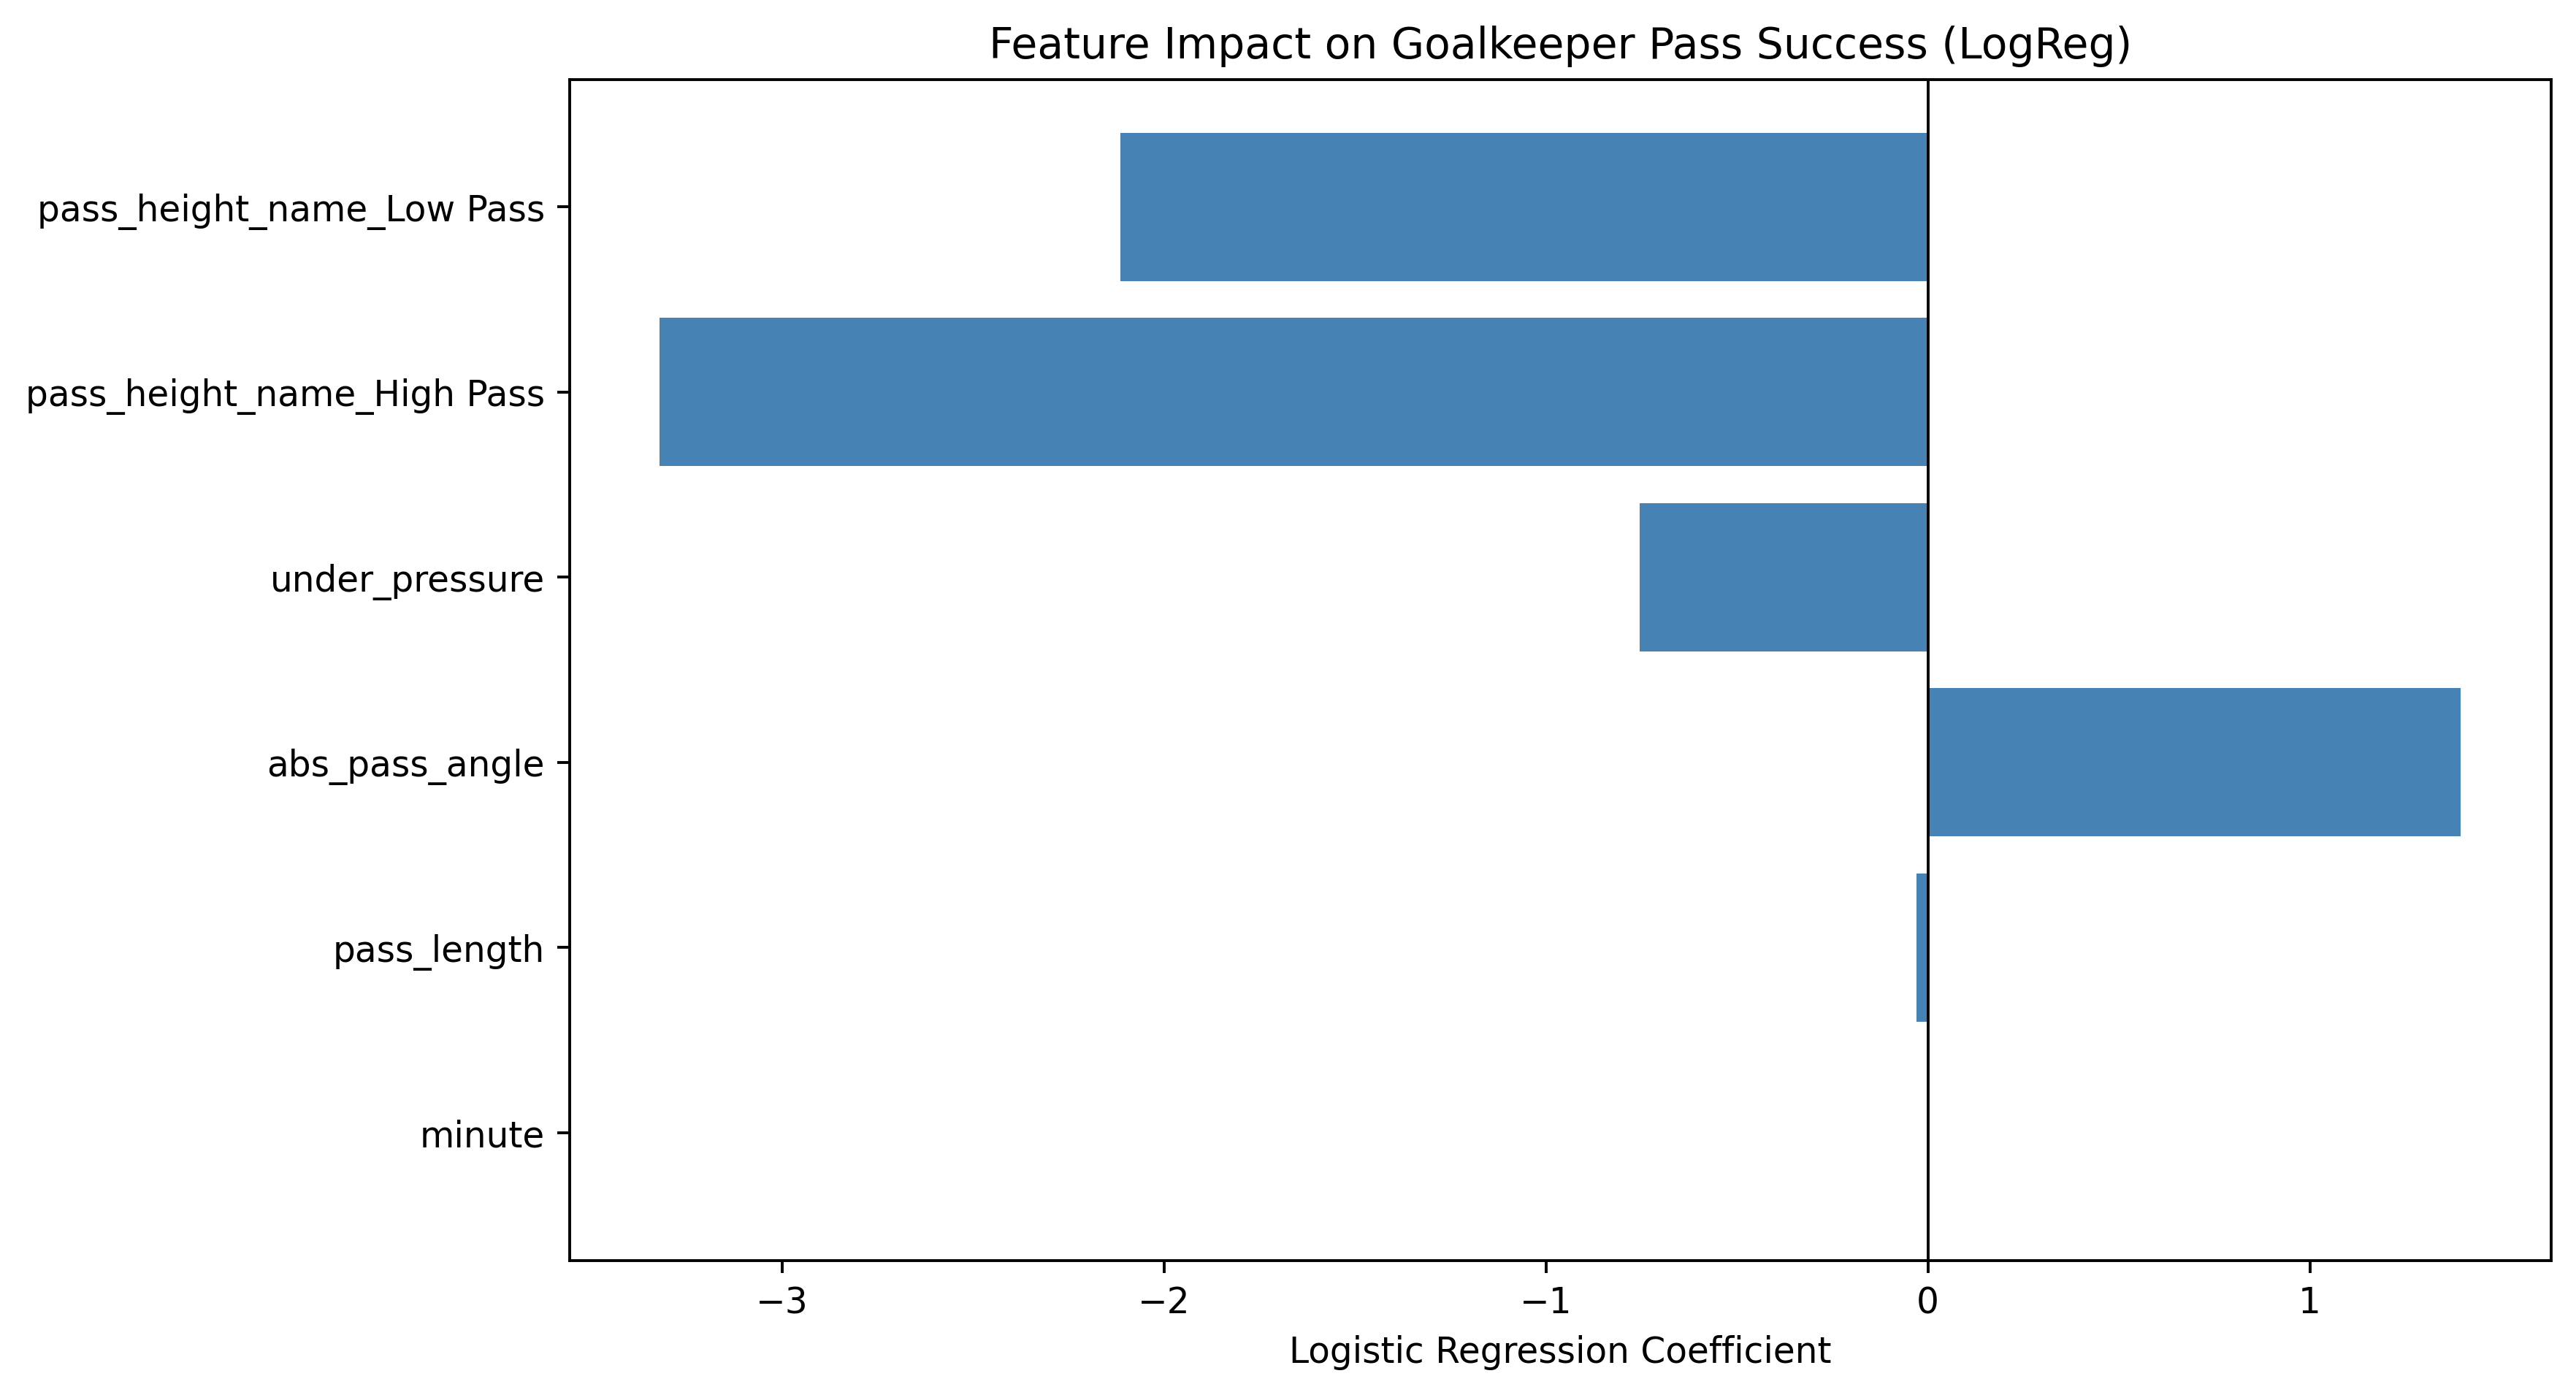

In [149]:
# plotting most important features
import matplotlib.cm as cm
feature_names = X_train.columns

# coefficients
coef = logreg_model.coef_[0]  # for binary logistic regression

# plot
plt.figure(figsize=(10,6), dpi = 350)

y_pos = np.arange(len(feature_names))
plt.barh(y_pos, coef, align='center', color = 'steelblue')
plt.yticks(y_pos, feature_names)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Feature Impact on Goalkeeper Pass Success (LogReg)")
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

gradient boosting

In [187]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# initializing XGBoost
xgb_model = XGBClassifier(
    n_estimators = 200,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 14,
    use_label_encoder = False,
    eval_metric = 'logloss')

# training
xgb_model.fit(X_train, y_train)

# predictions
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:,1]

# computing xRisk
gk_passes.loc[X_test.index, 'pred_prob_success_XGB'] = y_pred_prob
gk_passes.loc[X_test.index, 'xRisk_XGB'] = 1 - y_pred_prob

# evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))
print("\nClassification Report for xGBoost:\n", classification_report(y_test, y_pred))

Accuracy: 0.760387811634349
ROC-AUC: 0.8400974422378061

Classification Report for xGBoost:
               precision    recall  f1-score   support

           0       0.66      0.86      0.74      5543
           1       0.88      0.69      0.78      8175

    accuracy                           0.76     13718
   macro avg       0.77      0.78      0.76     13718
weighted avg       0.79      0.76      0.76     13718



/tmp/ipython-input-1576550712.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gain', y='feature', data=importance_df, palette='viridis')


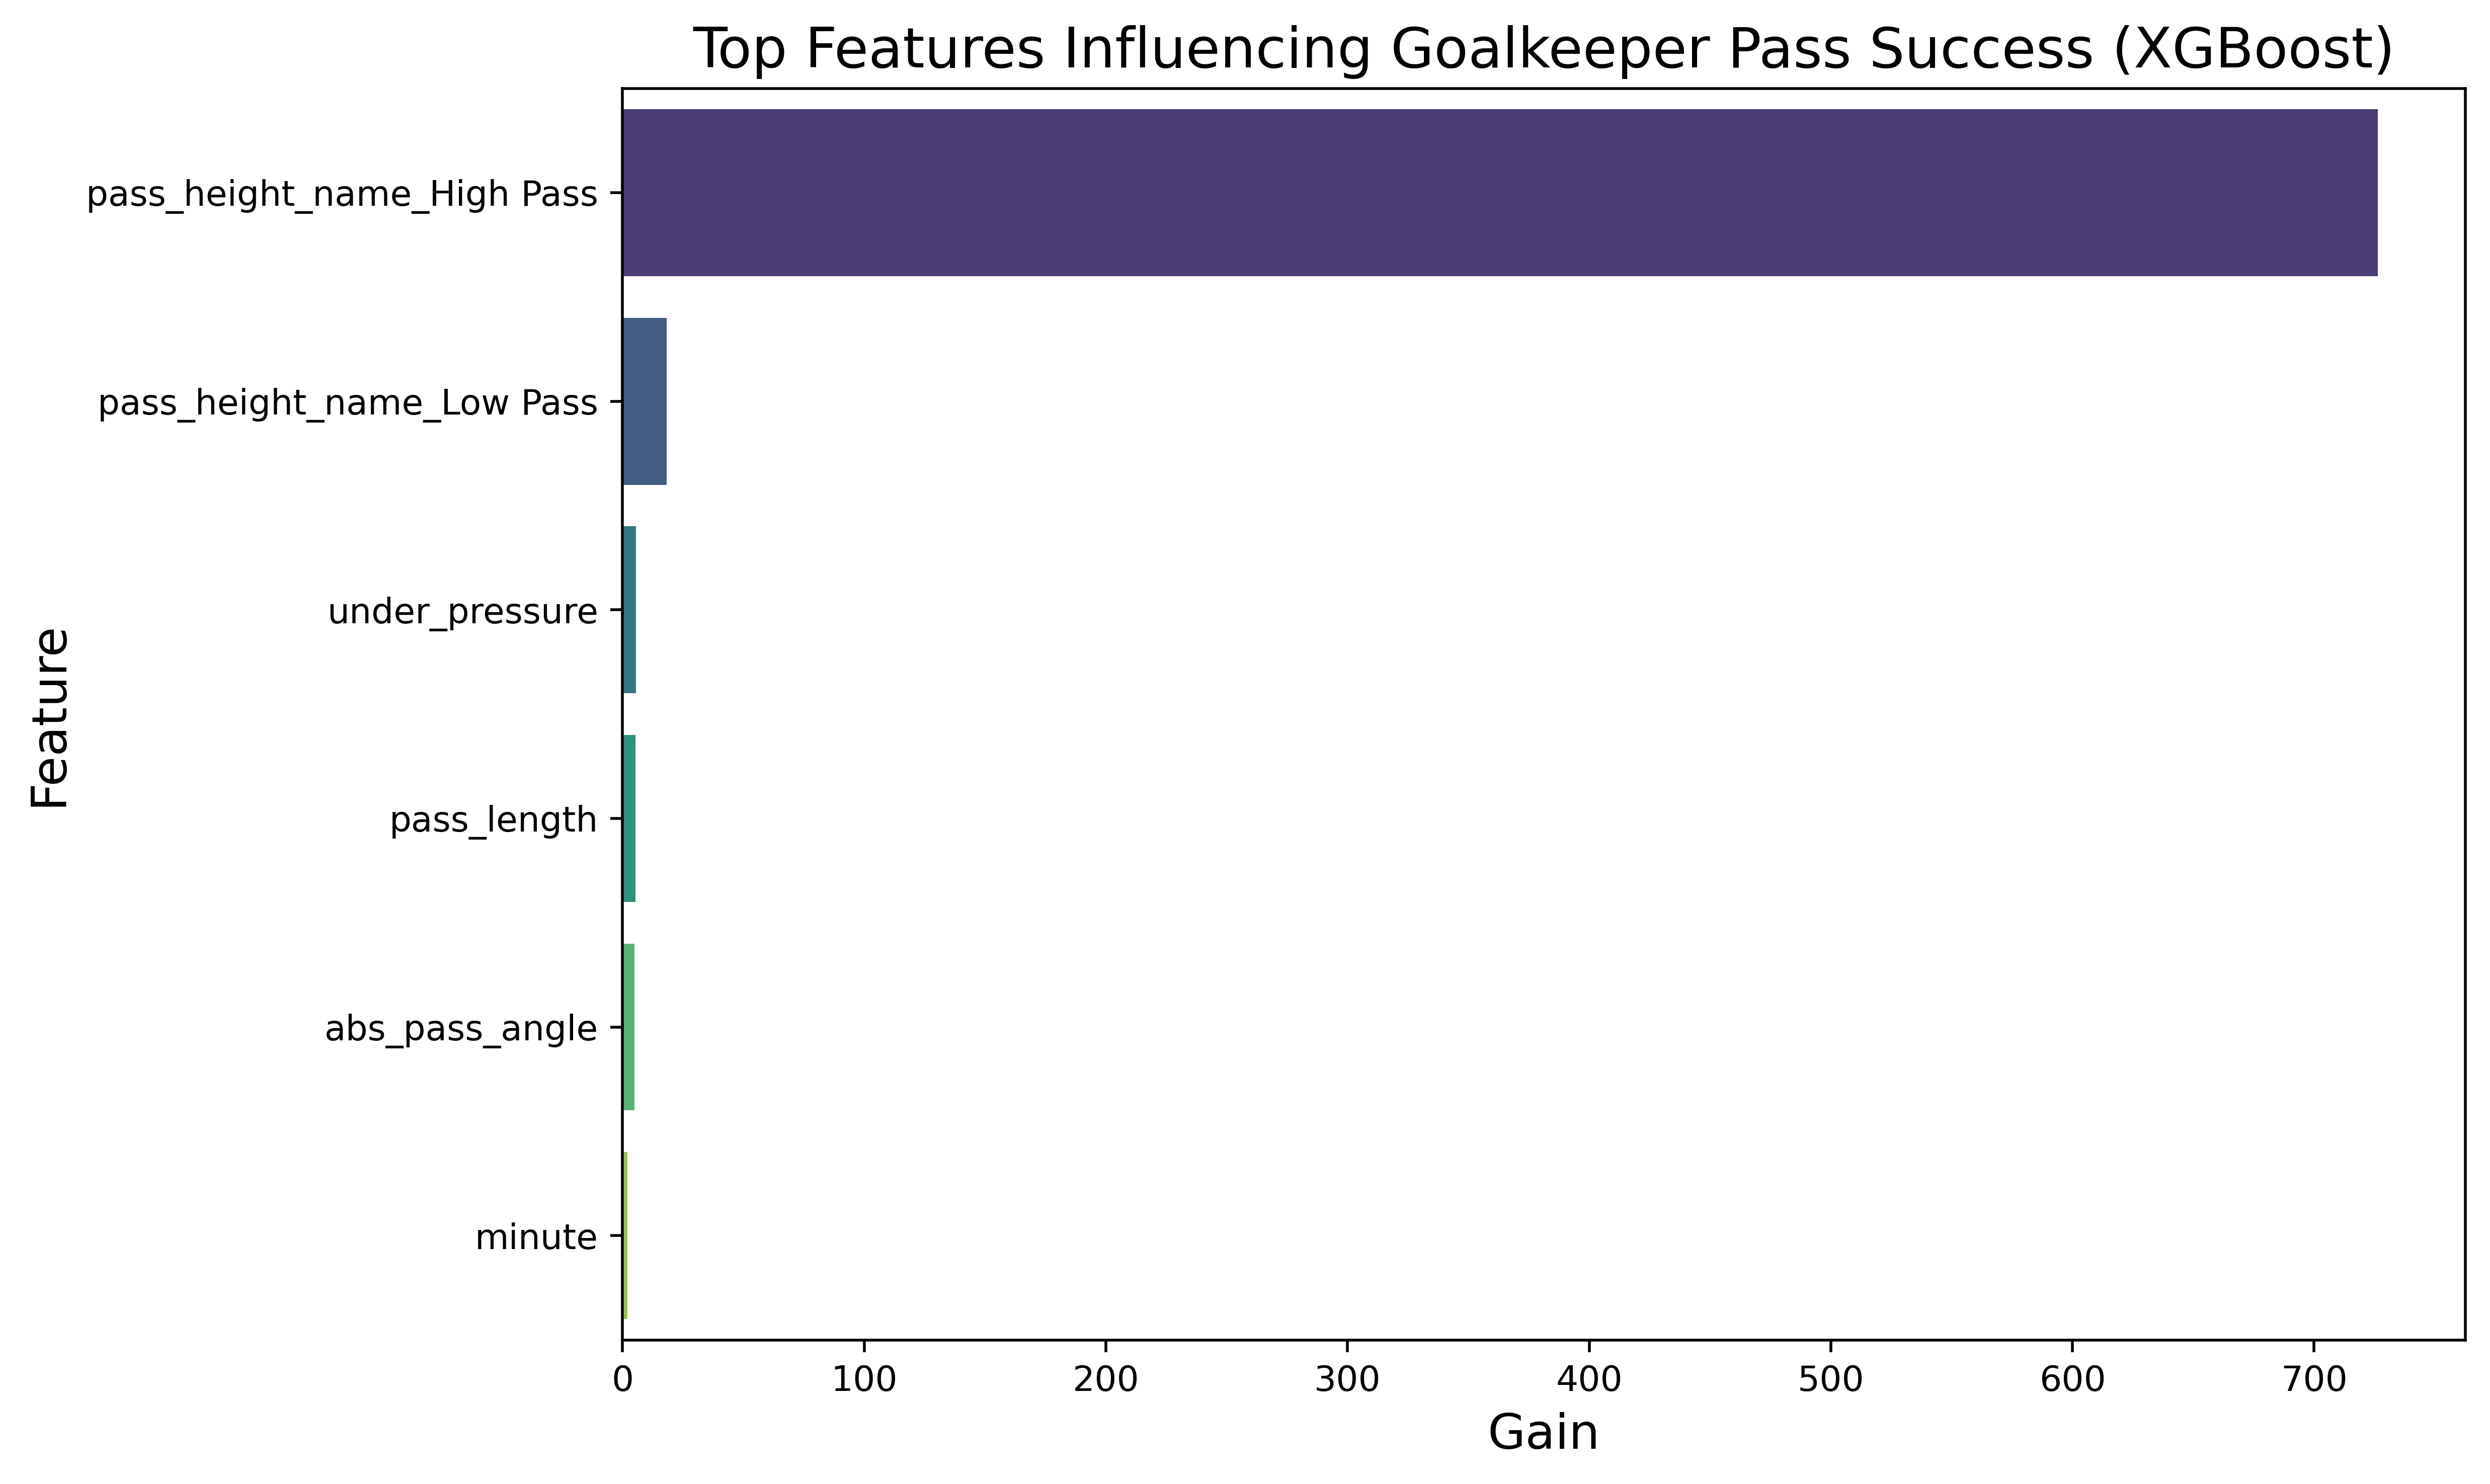

In [139]:
# plotting most important features
importance = xgb_model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance.keys()),
    'gain': list(importance.values())
}).sort_values(by='gain', ascending=False).head(10)

# plot
plt.figure(figsize=(10,6), dpi=500)
sns.barplot(x='gain', y='feature', data=importance_df, palette='viridis')
plt.title("Top Features Influencing Goalkeeper Pass Success (XGBoost)", fontsize=16)
plt.xlabel("Gain", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()

plotting risky regions

/usr/local/lib/python3.12/dist-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


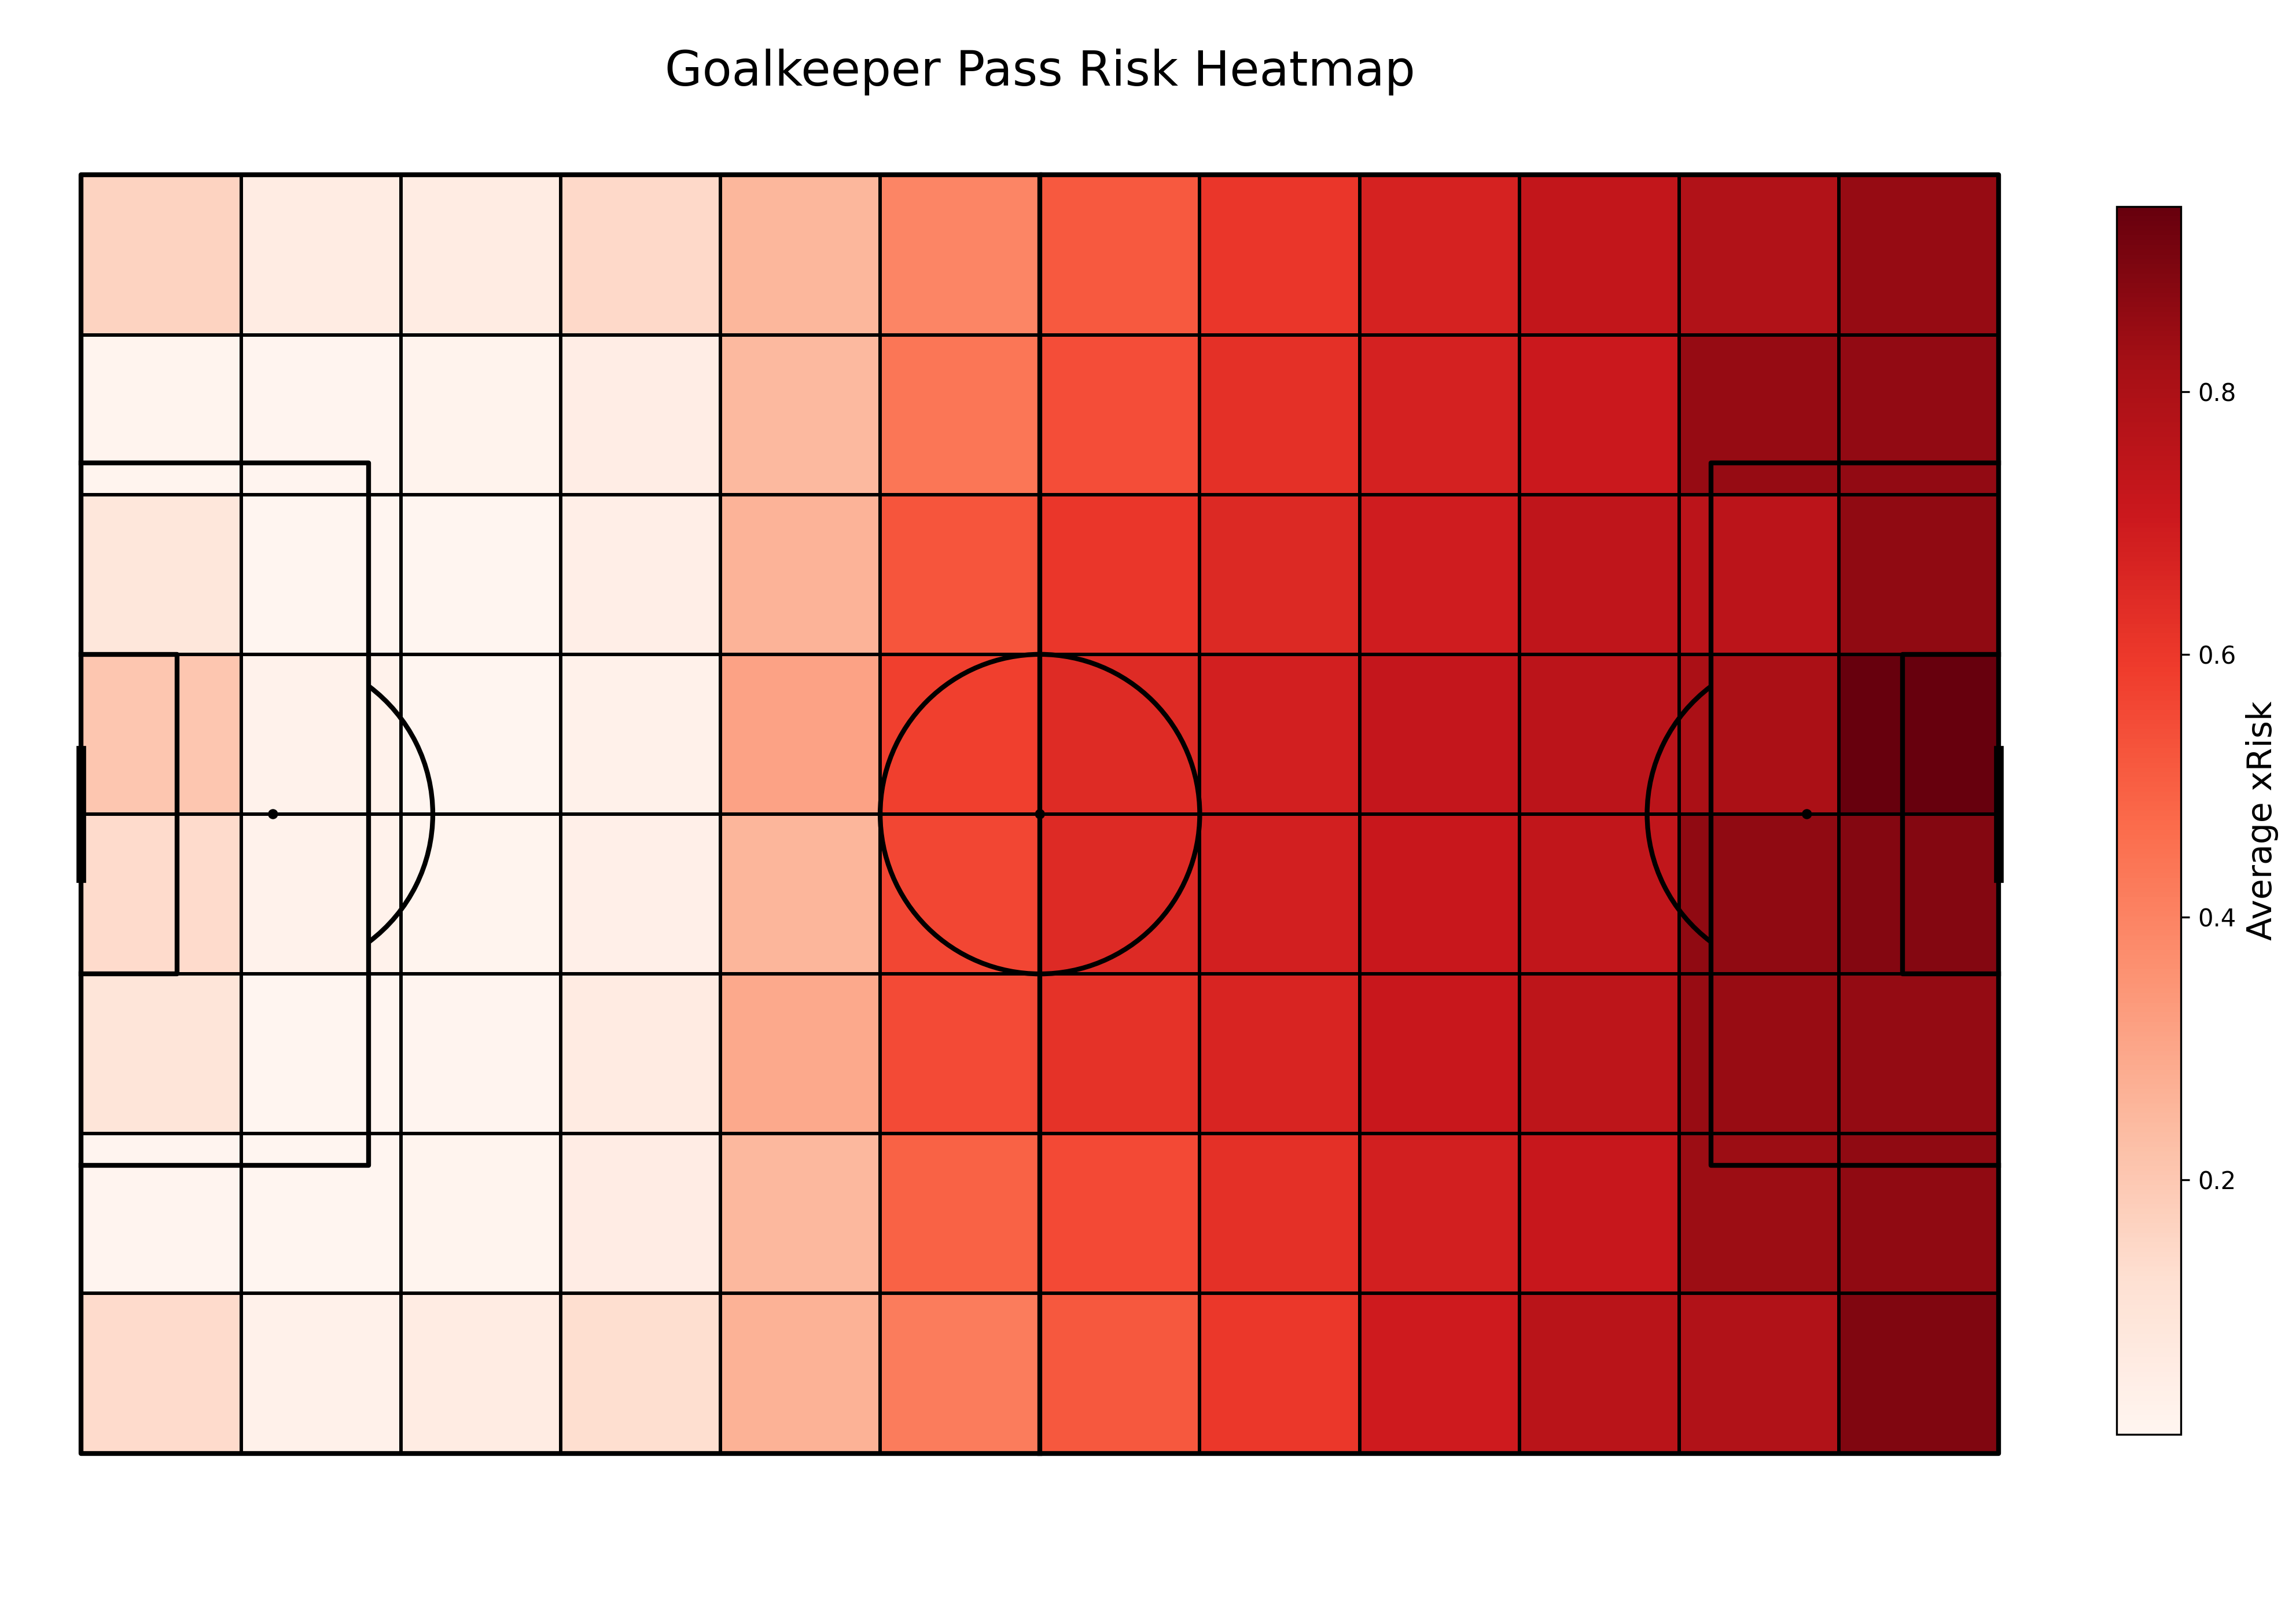

In [170]:
gk_passes['xRisk_plot'] = gk_passes['xRisk_XGB']

# creating pitch with grid
pitch = Pitch(line_zorder=2, line_color='black')
fig, ax = pitch.grid(grid_height=0.9, title_height=0.06, axis=False,
                     endnote_height=0.04, title_space=0, endnote_space=0)
fig.set_dpi(300)

# 2D statistic: average xRisk per bin
bin_statistic = pitch.bin_statistic(
    gk_passes['end_x'], gk_passes['end_y'],
    values=gk_passes['xRisk_plot'],
    statistic='mean',
    bins=(12, 8))

# heatmap
pcm = pitch.heatmap(
    bin_statistic, cmap='Reds', edgecolor='black', ax=ax['pitch'])

# colorbar
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)
cbar.set_label('Average xRisk', fontsize=14)

# title
fig.suptitle('Goalkeeper Pass Risk Heatmap', fontsize=20)
plt.show()

keepers who are good at completing 'risky' passes

In [174]:
# defining risky passes as those with xRisk > 0.4
risky_passes = gk_passes[gk_passes['xRisk_plot'] > 0.4]
successful_risky = risky_passes[risky_passes['pass_success'] == 1]

In [180]:
# aggregating by keeper
keeper_stats = risky_passes.groupby('player_name').agg(
    risky_passes_total=('xRisk_plot', 'count')).merge(
    successful_risky.groupby('player_name').agg(
        risky_passes_success=('xRisk_plot', 'count')),
    left_index=True, right_index=True)

# filtering only those who have made atleast 5 risky passes over the season
keeper_stats = keeper_stats[keeper_stats['risky_passes_total'] >= 5]

# computing success rate
keeper_stats['risky_pass_success_rate'] = keeper_stats['risky_passes_success'] / keeper_stats['risky_passes_total']

# sorting by success rate
keeper_stats = keeper_stats.sort_values(by='risky_pass_success_rate', ascending = False)

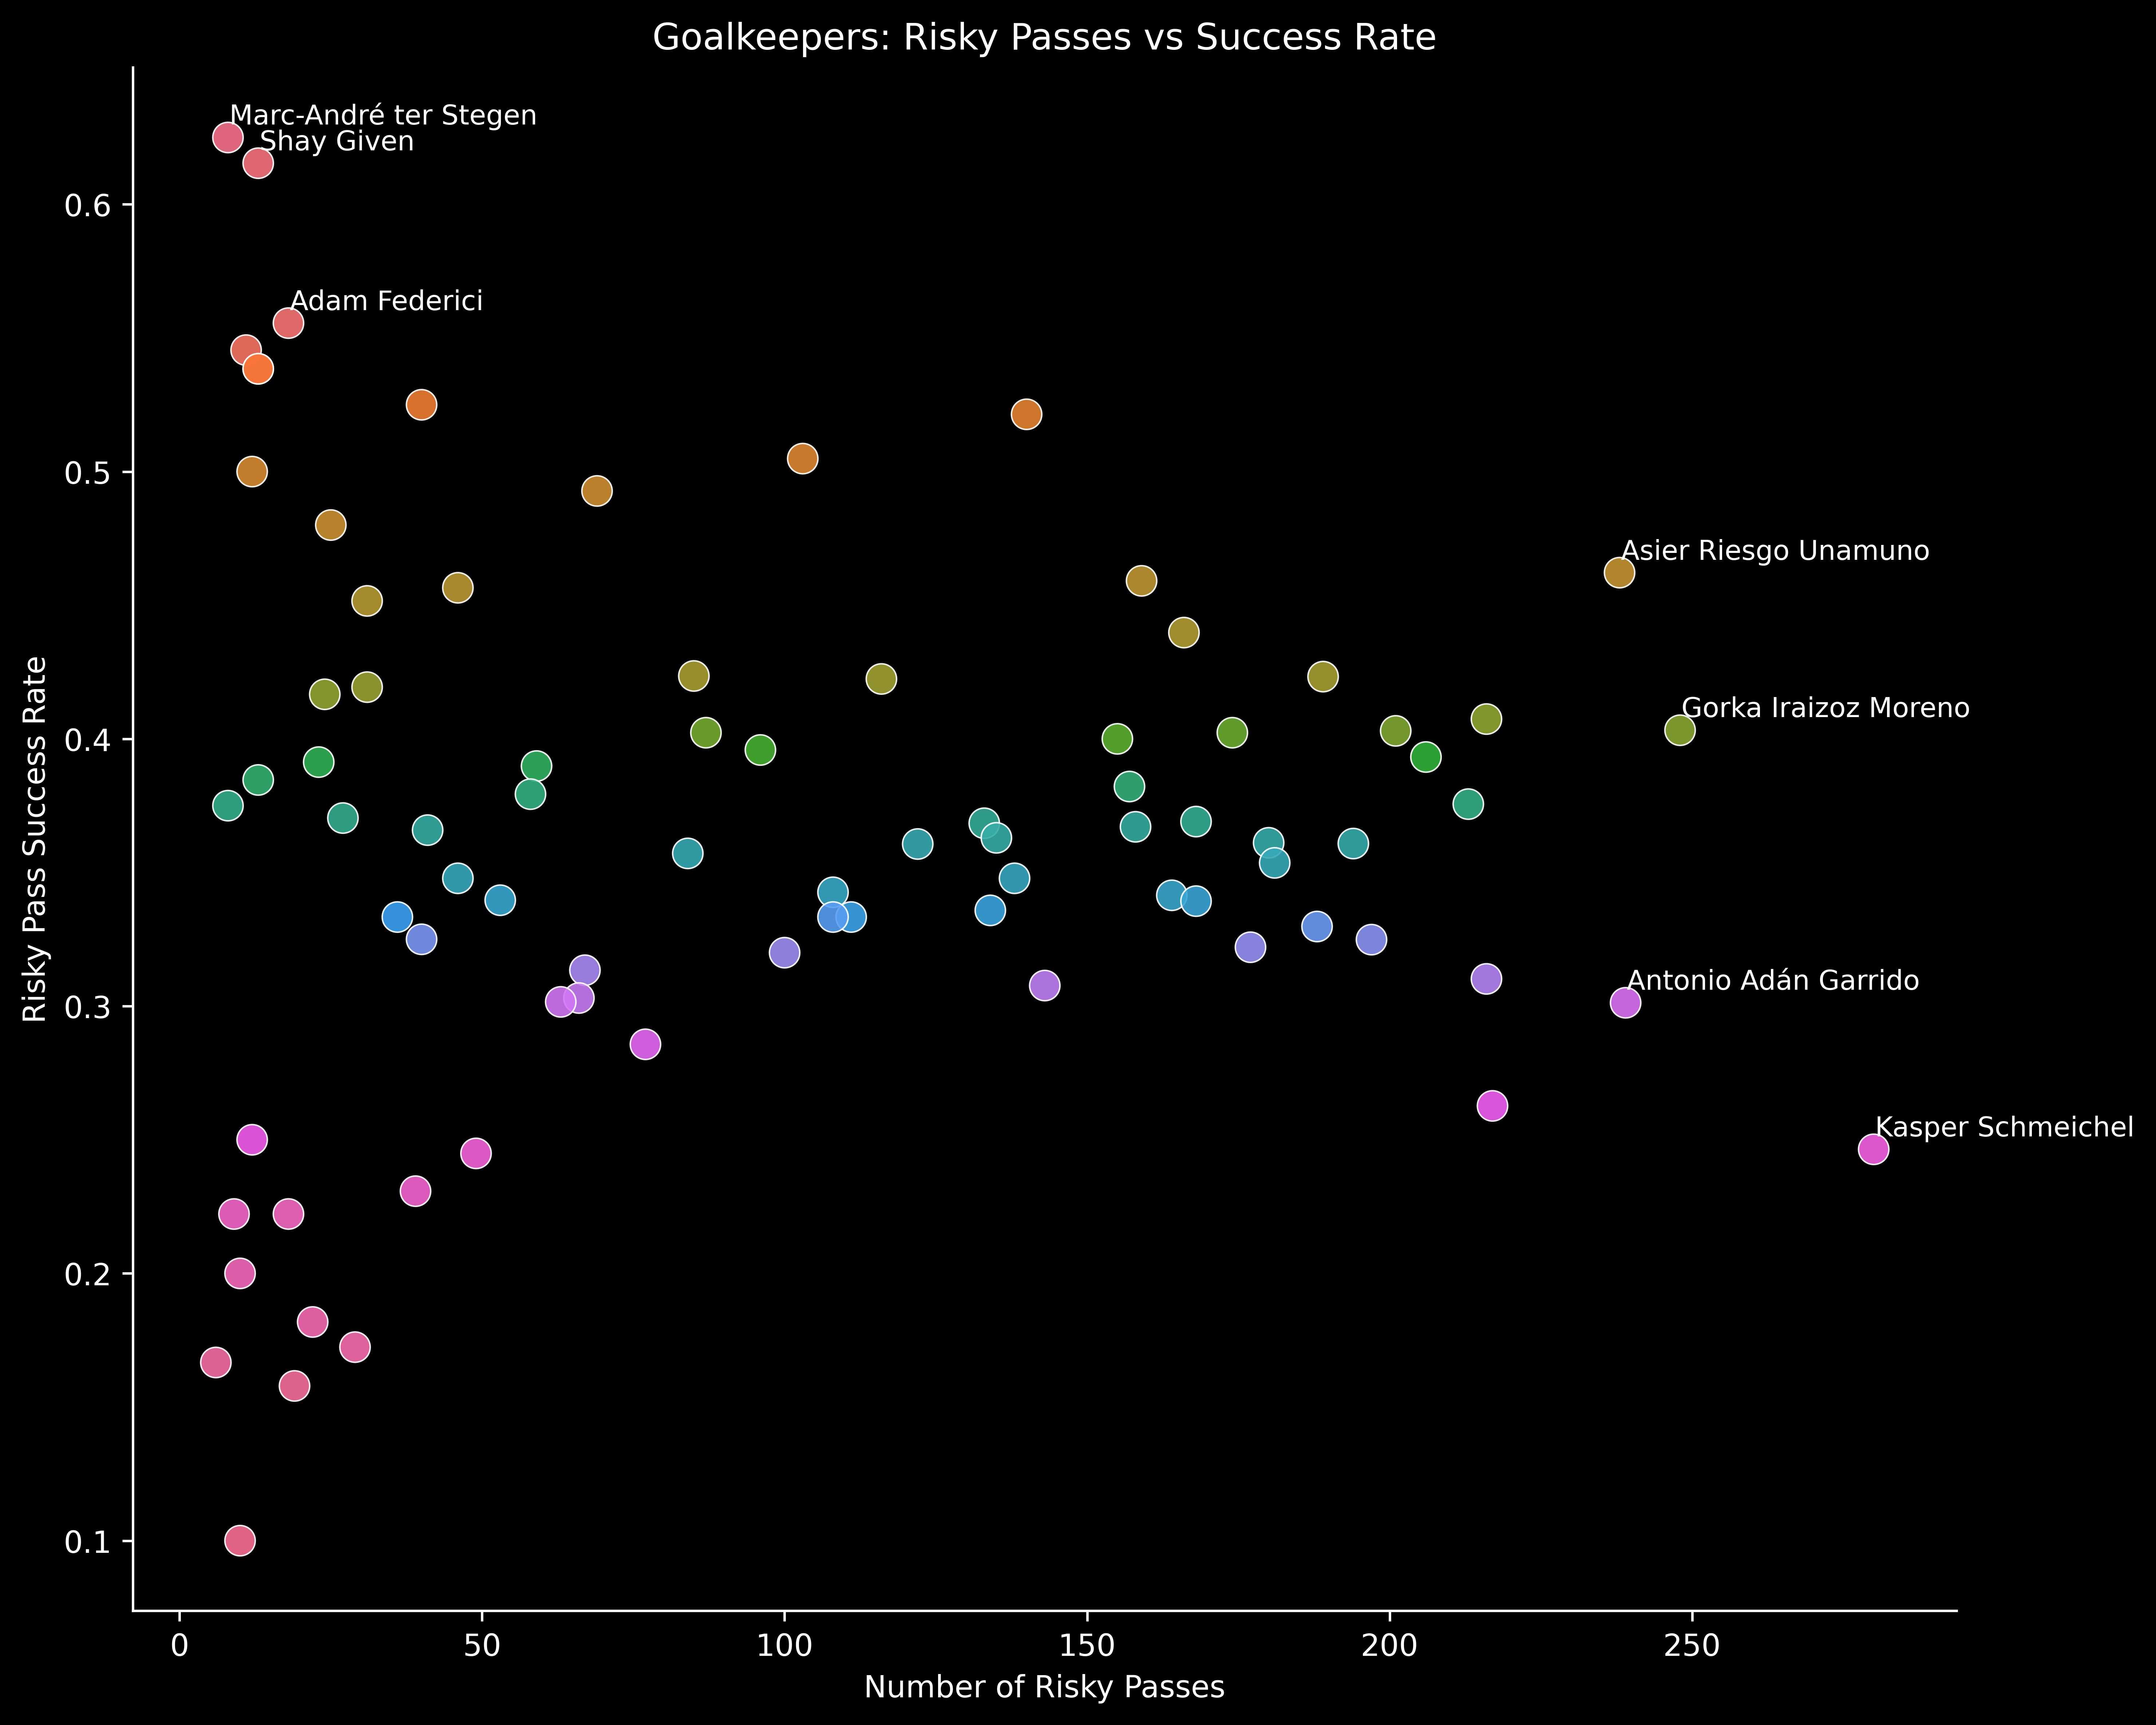

In [186]:
# scatterplot for volume of risky passes vs efficiency
plt.style.use("dark_background")
plt.figure(figsize=(10, 8), dpi=600)

# scatter plot: number of risky passes vs success rate
sns.scatterplot(
    data=keeper_stats.reset_index(),
    x='risky_passes_total',
    y='risky_pass_success_rate',
    hue='player_name',
    s=100, alpha=0.9, edgecolor='white', linewidth=0.5, legend = False)

# annotate standout keepers
for i, row in keeper_stats.reset_index().iterrows():
    if row['risky_passes_total'] > 230 or row['risky_pass_success_rate'] > 0.55:
        plt.text(
            row['risky_passes_total']+0.2,
            row['risky_pass_success_rate']+0.005,
            row['player_name'],
            fontsize=9,
            color='white')

plt.xlabel('Number of Risky Passes', color='white')
plt.ylabel('Risky Pass Success Rate', color='white')
plt.title('Goalkeepers: Risky Passes vs Success Rate', color='white')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()